
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [2]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "example.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


RasterioIOError: example.tif: No such file or directory


## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


# **แบบฝึกหัด 1**

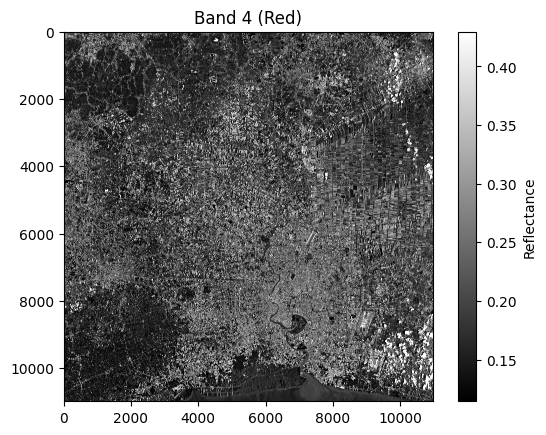

In [3]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

path = r"/content/T47PPR_20260405T033539_B04_10m.jp2"

with rasterio.open(path) as src:
    data = src.read(1).astype(float)
data = data / 10000.0

vmin, vmax = np.percentile(data, (2, 98))

plt.imshow(data, cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="Reflectance")
plt.title("Band 4 (Red)")
plt.show()

# **แบบฝึกหัด 2**

In [4]:
import rasterio

path =  r"/content/T47PPR_20260405T033539_B04_10m.jp2"

with rasterio.open(path) as src:
    print(src.meta)

{'driver': 'JP2OpenJPEG', 'dtype': 'uint16', 'nodata': None, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(10.0, 0.0, 600000.0,
       0.0, -10.0, 1600020.0)}


ข้อมูล metadata ที่ได้จากไฟล์ raster มีรายละเอียดดังนี้:
- **driver: JP2OpenJPEG**  
  ประเภทของไฟล์ raster ในที่นี้คือ JPEG2000 ซึ่งเป็นไฟล์จากข้อมูลดาวเทียม Sentinel-2  
- **dtype: uint16**  
  ชนิดข้อมูลของ pixel เป็นจำนวนเต็ม 16 บิต ใช้แทนค่าการสะท้อนแสง
- **nodata: None**  
  ไม่มีการกำหนดค่าที่เป็นข้อมูลสูญหาย
- **width: 10980**  
  ความกว้างของภาพในหน่วย pixel  
- **height: 10980**  
  ความสูงของภาพในหน่วย pixel  
- **count: 1**  
  จำนวน band ของภาพ
- **crs: WGS 84 / UTM zone 47N**  
  ระบบพิกัดของข้อมูล ใช้หน่วยเป็นเมตร เหมาะสำหรับการวิเคราะห์เชิงพื้นที่  
- **transform: Affine transformation**  
  ใช้สำหรับแปลงตำแหน่ง pixel ไปเป็นพิกัดจริงบนโลก  
  โดยค่าที่ได้แสดงว่า pixel มีขนาด 10 เมตร และมีพิกัดจุดเริ่มต้นของภาพอยู่ที่มุมซ้ายบน

# **แบบฝึกหัด 3**

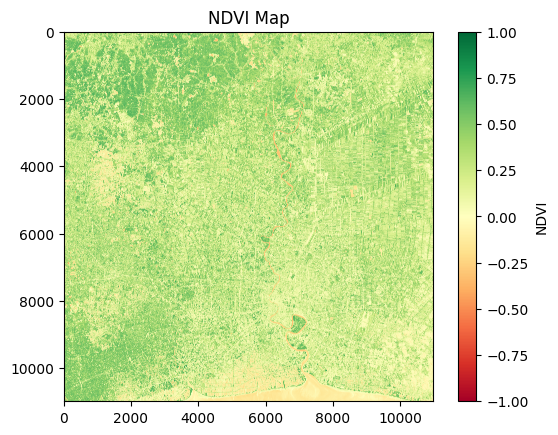

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

red_path = r"/content/T47PPR_20260405T033539_B04_10m.jp2"
nir_path = r"/content/T47PPR_20260405T033539_B08_10m.jp2"

red = rasterio.open(red_path).read(1).astype(float) / 10000
nir = rasterio.open(nir_path).read(1).astype(float) / 10000

ndvi = (nir - red) / (nir + red + 1e-10)

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI Map")
plt.show()

# **แบบฝึกหัด 4**

In [2]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

raster_path = r"/content/T47PPR_20260405T033539_B04_10m.jp2"
shapefile_path = r"/content/gadm41_THA_1.shp"

gdf = gpd.read_file(shapefile_path)

bangkok = gdf[gdf['NAME_1'] == "Bangkok Metropolis"]

with rasterio.open(raster_path) as src:
    bangkok = bangkok.to_crs(src.crs)

    geom = [mapping(bangkok.geometry.values[0])]

    out_image, out_transform = mask(src, geom, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

output_path = r"/content/bangkok_clip.tif"

with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

output_path = r"/content/bangkok_clip.tif"

with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)


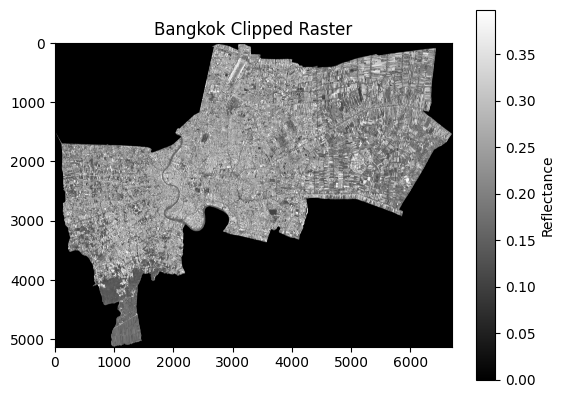

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = out_image[0].astype(float) / 10000

vmin, vmax = np.percentile(data, (2, 98))

plt.imshow(data, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Bangkok Clipped Raster")
plt.colorbar(label="Reflectance")
plt.show()